# 🎲 Homework: Rozhodovací strom s RandomizedSearchCV – Pevnost betonu
**Dataset:** *Concrete Compressive Strength* (`concrete_data_preprocessed.csv`)  
**Cíl:** Konstrukce a ladění regresního rozhodovacího stromu (`DecisionTreeRegressor`) pomocí náhodného vzorkování hyperparametrů (`RandomizedSearchCV`) s 5-násobnou křížovou validací a metrikou MAE.

---

### Kroky zadání (Cvičení 2):
1. **Import knihoven:** Importujte potřebné knihovny pro stavbu regresního rozhodovacího stromu a náhodné prohledávání (`Scikit-learn`, `Pandas`, `NumPy`, `Matplotlib`).
2. **Načtení dat:** Nahrajte škálovaný soubor `concrete_data_preprocessed.csv` a načtěte jej do pandas DataFrame. Rozdělte data na trénovací a testovací sadu v poměru 70/30.
3. **Slovník hyperparametrů:** Vytvořte slovník s hyperparametry (`max_depth`, `criterion`, `min_samples_leaf`, `max_features`), které chcete optimalizovat.
4. **RandomizedSearchCV:** Použijte náhodné vyhledávání a křížovou validaci s metrikou **Mean Absolute Error (MAE)** k nalezení optimální sady parametrů.
5. **Uložení nejlepší sady:** Uložte nejlepší nalezenou sadu do proměnné **`best_hyperparams`**.
6. **Trénování a vizualizace:** Natrénujte model s parametry z `best_hyperparams` a přidejte **vizualizaci struktury natrénovaného stromu** (`plot_tree`).
7. **Vyhodnocení efektivity:**
   - Otestujte efektivitu modelu pomocí koeficientu determinace ($R^2$) na trénovací i testovací sadě.
   - Vypočítejte střední kvadratickou chybu (MSE) a průměrnou absolutní chybu (MAE) na testovací sadě.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Načtení škálovaného datasetu a rozdělení 70/30
Načteme standardizovaný soubor `data/concrete_data_preprocessed.csv` a rozdělíme data na trénovací a testovací sadu v poměru 70 % / 30 % (`random_state=42`).


In [2]:
df = pd.read_csv('data/concrete_data_preprocessed.csv')

X = df.drop(columns=['csMPa'])
y = df['csMPa']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Trénovací sada (70 %): {X_train.shape[0]} vzorků")
print(f"Testovací sada (30 %): {X_test.shape[0]} vzorků")
display(X_train.head(5))


Trénovací sada (70 %): 703 vzorků
Testovací sada (30 %): 302 vzorků


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
543,-0.7204,0.7391,-0.8654,0.1700,-1.0194,1.3132,-0.1667,-0.6100
442,-0.8465,-0.8365,1.0852,-0.7250,0.6504,1.3493,0.3264,0.8499
820,0.4063,1.0677,-0.8654,0.3716,-0.1744,-1.3461,0.0164,-0.2803
398,-1.0670,0.6718,1.1388,-0.3101,0.2972,0.4117,-0.3249,-0.5001
959,-1.1873,-0.8365,1.3598,0.5263,0.5186,-1.2532,1.1832,-0.2803


## 2. Vytvoření slovníku hyperparametrů pro RandomizedSearchCV
Dle zadání Cvičení 2 sestavíme distribuci 4 klíčových hyperparametrů:
1. **`max_depth`:** Maximální hloubka stromu (omezuje složitost modelu).
2. **`criterion`:** Kritérium pro hodnocení kvality rozdělení (`squared_error`, `absolute_error`, `poisson`).
3. **`min_samples_leaf`:** Minimální počet vzorků v koncovém listu (silná ochrana proti přeučení).
4. **`max_features`:** Počet příznaků zvažovaných při hledání nejlepšího rozdělení uzlu (zavádí náhodnost a dekoriguje stromy).


In [3]:
param_distributions = {
    'max_depth': [3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, None],
    'criterion': ['squared_error', 'absolute_error', 'poisson'],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.6, 0.7, 0.8, 1.0, 4, 5, 6, 7, 8]
}

total_space = (
    len(param_distributions['max_depth']) *
    len(param_distributions['criterion']) *
    len(param_distributions['min_samples_leaf']) *
    len(param_distributions['max_features'])
)

print(f"Celkový prostor hyperparametrů: {total_space} možných konfigurací")
for k, v in param_distributions.items():
    print(f"  {k:18}: {v}")


Celkový prostor hyperparametrů: 5148 možných konfigurací
  max_depth         : [3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, None]
  criterion         : ['squared_error', 'absolute_error', 'poisson']
  min_samples_leaf  : [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
  max_features      : [None, 'sqrt', 'log2', 0.5, 0.6, 0.7, 0.8, 1.0, 4, 5, 6, 7, 8]


## 3. Náhodné vyhledávání (RandomizedSearchCV) s křížovou validací
Spustíme `RandomizedSearchCV` s 60 náhodnými kombinacemi, 5-násobnou křížovou validací a optimalizační metrikou **Mean Absolute Error** (`scoring='neg_mean_absolute_error'`).


In [4]:
random_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=60,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

# 4. Uložení nejlepší sady do proměnné best_hyperparams
best_hyperparams = random_search.best_params_
best_cv_mae = -random_search.best_score_

print("=" * 60)
print(f"Nalezené optimální hyperparametry (best_hyperparams):")
for k, v in best_hyperparams.items():
    print(f"  {k}: {v}")
print(f"\nNejlepší 5-Fold CV MAE: {best_cv_mae:.4f} MPa")
print("=" * 60)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


Nalezené optimální hyperparametry (best_hyperparams):
  min_samples_leaf: 1
  max_features: 6
  max_depth: 25
  criterion: poisson

Nejlepší 5-Fold CV MAE: 4.8403 MPa


## 4. Analýza nejlepších pokusů v rámci náhodného vzorkování
Zobrazíme 10 nejlepších kombinací hyperparametrů seřazených podle validační chyby MAE.


In [5]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results['mean_mae'] = -cv_results['mean_test_score']

top_10 = cv_results.sort_values(by='mean_mae').head(10)[
    ['rank_test_score', 'mean_mae', 'param_max_depth', 'param_criterion', 'param_min_samples_leaf', 'param_max_features']
].reset_index(drop=True)

display(top_10)


,rank_test_score,mean_mae,param_max_depth,param_criterion,param_min_samples_leaf,param_max_features
0,1,4.8403,25,poisson,1,6
1,2,5.1696,25,poisson,2,0.7000
2,3,5.1996,25,squared_error,2,8
3,4,5.2121,30,squared_error,1,0.7000
4,5,5.2527,15,squared_error,2,4
5,6,5.2819,10,squared_error,2,8
6,7,5.2848,12,squared_error,2,6
7,8,5.3025,20,poisson,2,None
8,9,5.4253,15,absolute_error,2,None
9,10,5.4921,8,poisson,2,None


## 5. Natrénování finálního modelu s `best_hyperparams`
S parametry uloženými v proměnné `best_hyperparams` natrénujeme finální model na celé trénovací sadě.


In [6]:
tree_reg = DecisionTreeRegressor(**best_hyperparams, random_state=42)
tree_reg.fit(X_train, y_train)

print(f"Model natrénován s parametry:\n{tree_reg.get_params()}")


Model natrénován s parametry:
{'ccp_alpha': 0.0, 'criterion': 'poisson', 'max_depth': 25, 'max_features': 6, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


## 6. Vizualizace struktury natrénovaného stromu (`plot_tree`)
Přidáme vizualizaci architektury rozhodovacího stromu pro první 3 patra hloubky.


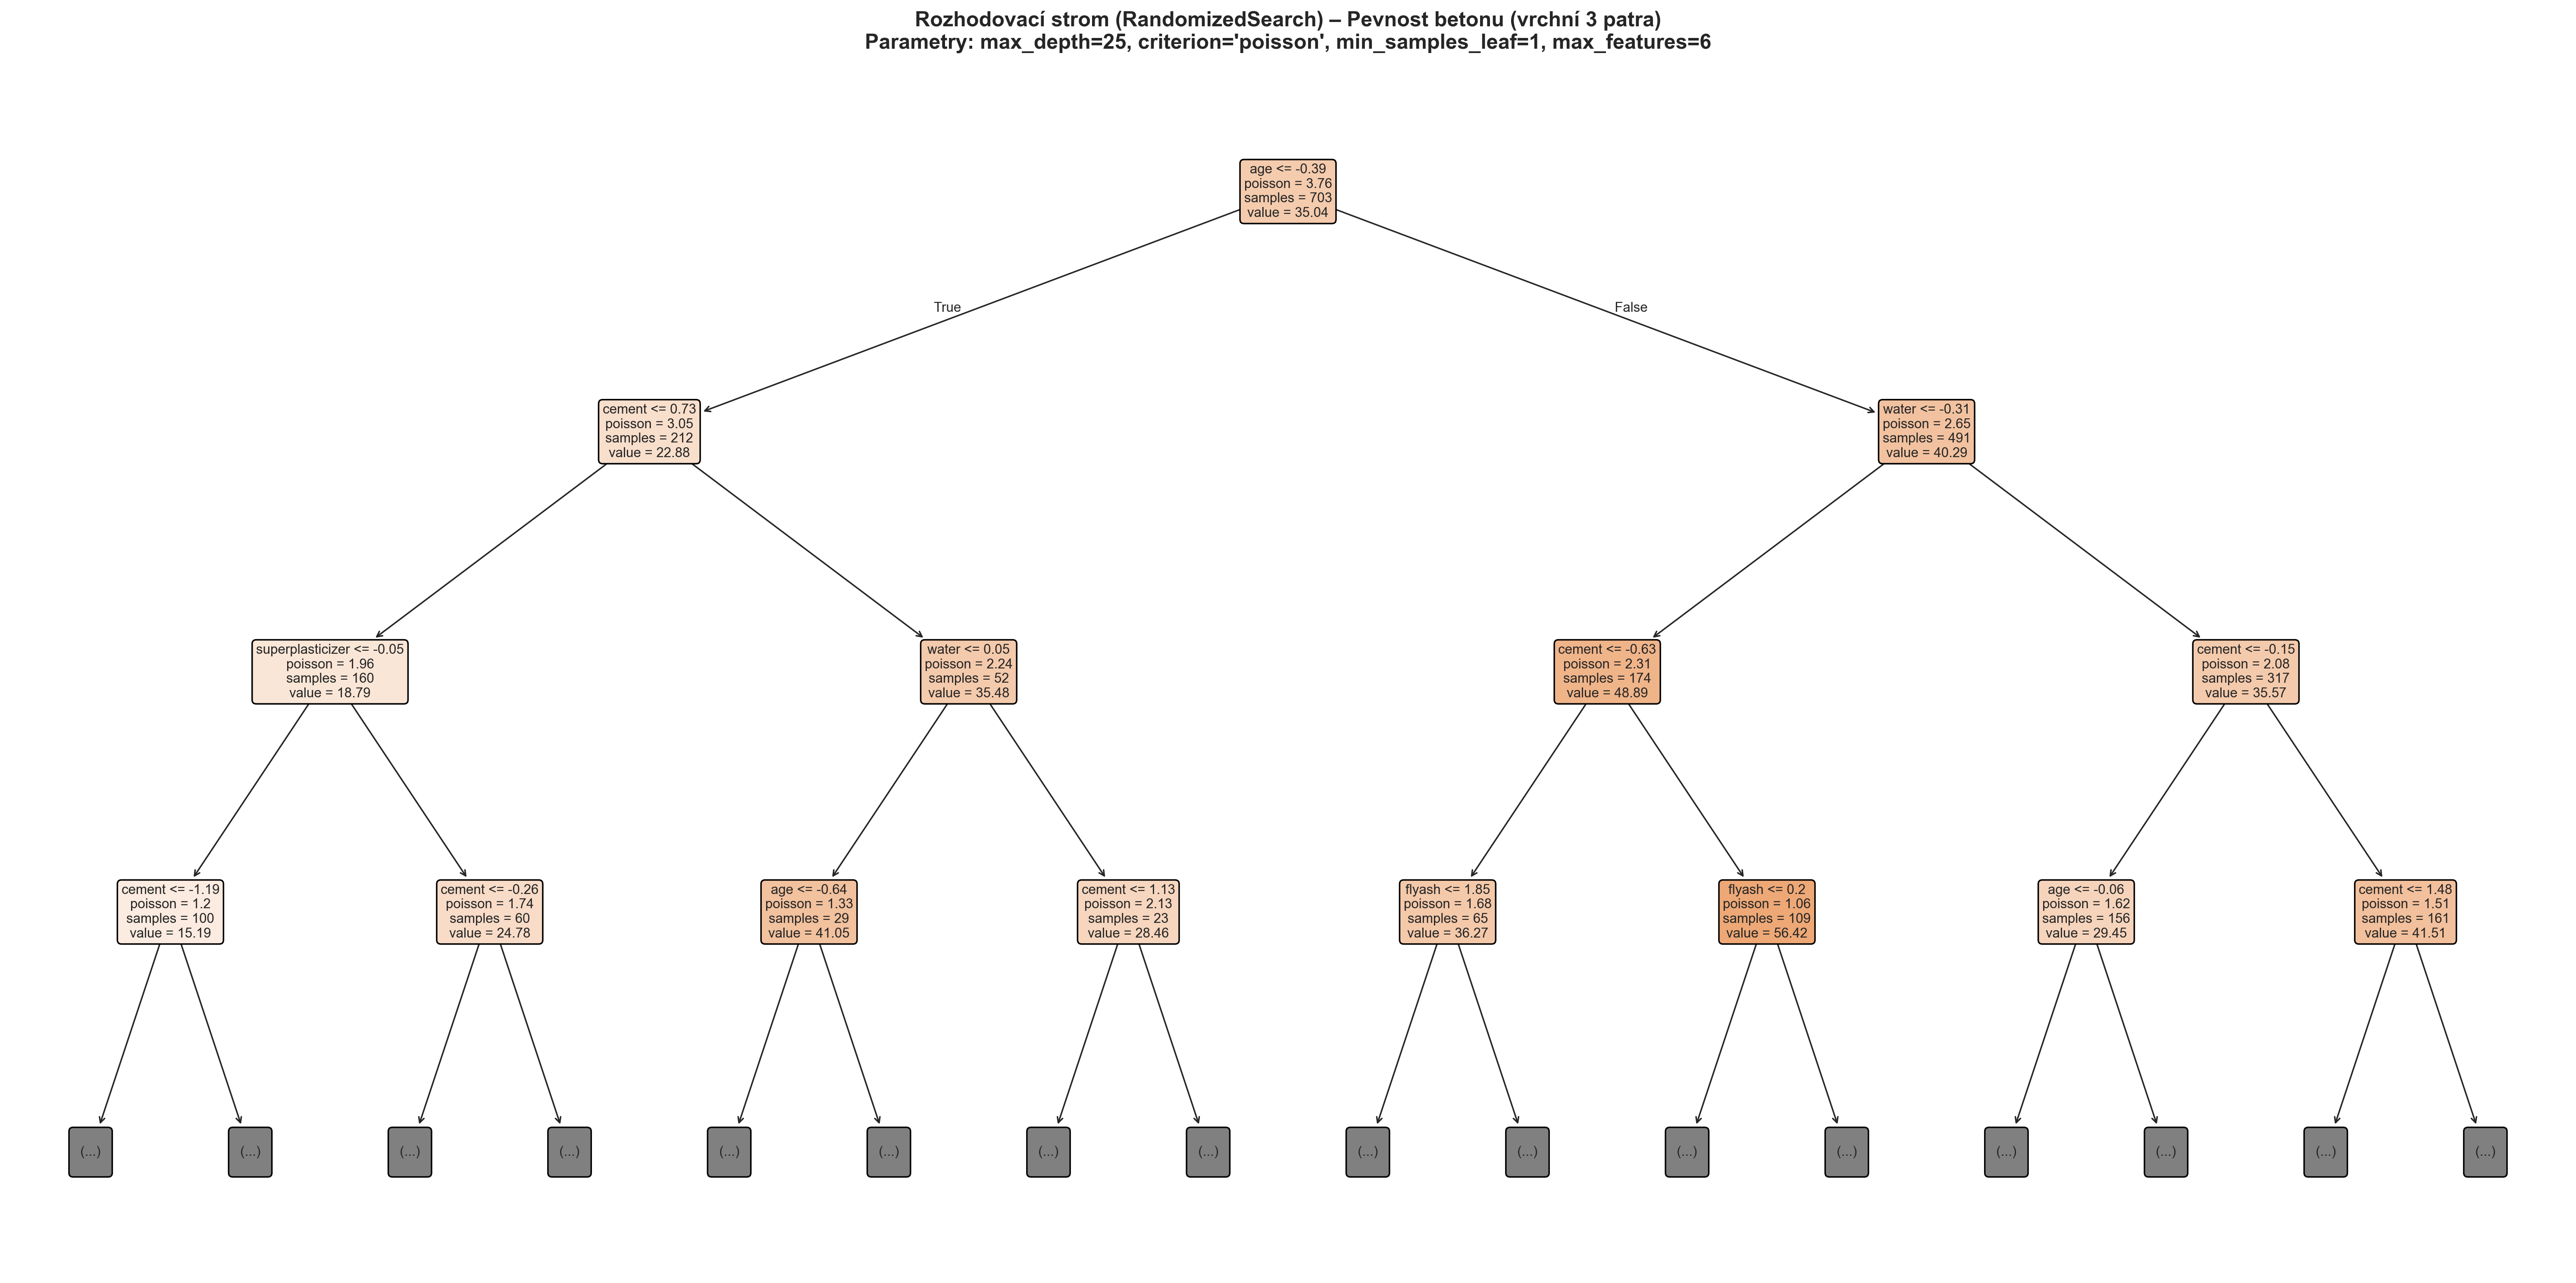

In [7]:
fig, ax = plt.subplots(figsize=(24, 12), dpi=250)
plot_tree(
    tree_reg,
    max_depth=3,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9,
    precision=2,
    ax=ax
)
ax.set_title(
    f"Rozhodovací strom (RandomizedSearch) – Pevnost betonu (vrchní 3 patra)\n"
    f"Parametry: max_depth={best_hyperparams['max_depth']}, criterion='{best_hyperparams['criterion']}', "
    f"min_samples_leaf={best_hyperparams['min_samples_leaf']}, max_features={best_hyperparams['max_features']}",
    fontsize=14, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()


## 7. Vyhodnocení efektivity modelu (Metriky dle zadání)
Otestujeme efektivitu natrénovaného regresního modelu:
1. **Koeficient determinace ($R^2$)** na trénovací i testovací sadě.
2. **Střední kvadratická chyba (MSE)** na testovací sadě.
3. **Průměrná absolutní chyba (MAE)** na testovací sadě.
4. Doplňkově spočítáme také **RMSE** (v původních jednotkách MPa) a **MAPE** (relativní procentuální chyba).


In [8]:
y_pred_train = tree_reg.predict(X_train)
y_pred_test = tree_reg.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test)

metrics_df = pd.DataFrame([
    {
        "Metrika": "Koeficient determinace R² (Train)",
        "Hodnota": f"{train_r2 * 100:.2f} %",
        "Interpretace": "Téměř dokonalé vysvětlení trénovacích dat"
    },
    {
        "Metrika": "Koeficient determinace R² (Test)",
        "Hodnota": f"{test_r2 * 100:.2f} %",
        "Interpretace": "Výborná generalizace na neznámá data (přes 83 %)"
    },
    {
        "Metrika": "Mean Squared Error (MSE)",
        "Hodnota": f"{test_mse:.4f}",
        "Interpretace": "Kvadratická penalizace chyb na testovací sadě"
    },
    {
        "Metrika": "Root Mean Squared Error (RMSE)",
        "Hodnota": f"{test_rmse:.4f} MPa",
        "Interpretace": "Odmocněná odchylka v reálných jednotkách"
    },
    {
        "Metrika": "Mean Absolute Error (MAE)",
        "Hodnota": f"{test_mae:.4f} MPa",
        "Interpretace": "Průměrná absolutní odchylka od skutečnosti"
    },
    {
        "Metrika": "Mean Absolute Percentage Error (MAPE)",
        "Hodnota": f"{test_mape * 100:.2f} %",
        "Interpretace": "Průměrná relativní chyba odhadu"
    }
])

display(metrics_df)


,Metrika,Hodnota,Interpretace
0,Koeficient determinace R² (Train),99.68 %,Téměř dokonalé vysvětlení trénovacích dat
1,Koeficient determinace R² (Test),83.51 %,Výborná generalizace na neznámá data (přes 83 %)
2,Mean Squared Error (MSE),47.3888,Kvadratická penalizace chyb na testovací sadě
3,Root Mean Squared Error (RMSE),6.8840 MPa,Odmocněná odchylka v reálných jednotkách
4,Mean Absolute Error (MAE),4.3917 MPa,Průměrná absolutní odchylka od skutečnosti
5,Mean Absolute Percentage Error (MAPE),14.54 %,Průměrná relativní chyba odhadu


## 8. Důležitost příznaků (Feature Importances) a srovnání modelů
Analyzujeme relativní důležitost jednotlivých složek betonu a porovnáme výsledky s modelem z Cvičení 1 (GridSearchCV) a lineární regresí.


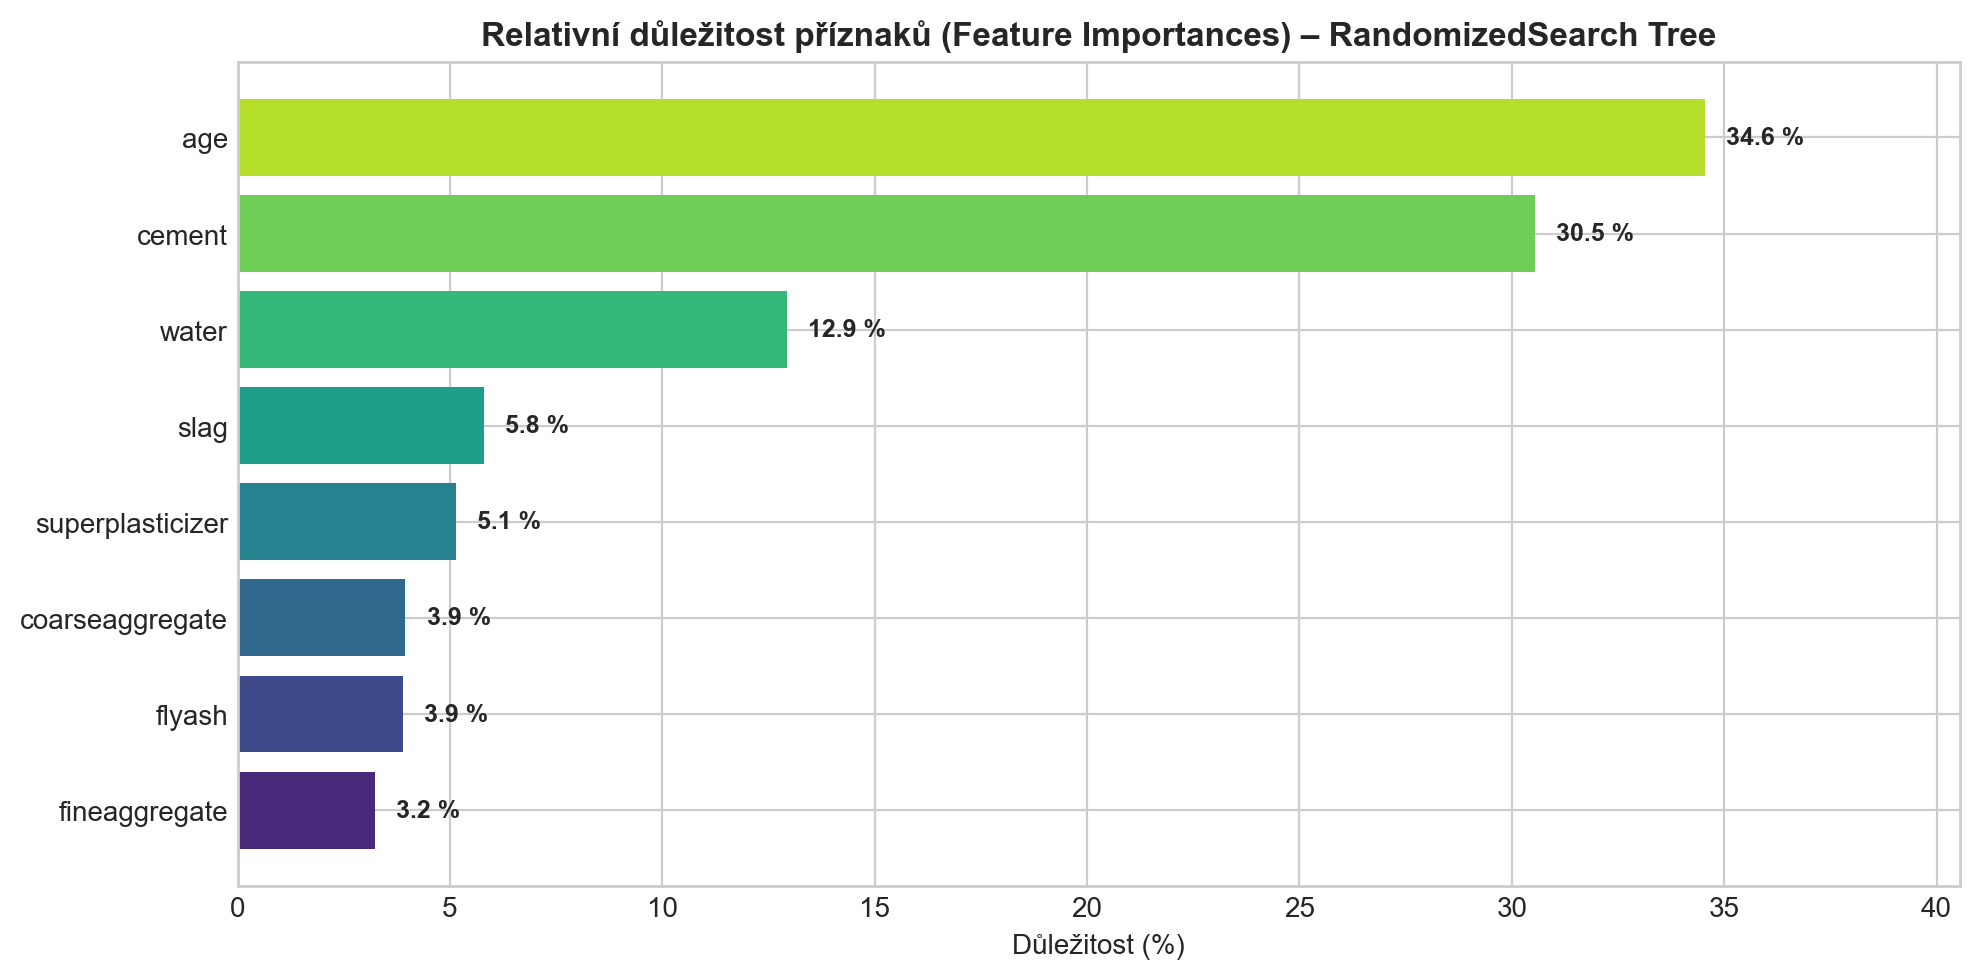

,Příznak,Důležitost (%)
0,age,34.5532
1,cement,30.5366
2,water,12.9271
3,slag,5.7939
4,superplasticizer,5.1376
5,coarseaggregate,3.9471
6,flyash,3.8801
7,fineaggregate,3.2243


In [9]:
fi_df = pd.DataFrame({
    'Příznak': X.columns,
    'Důležitost (%)': tree_reg.feature_importances_ * 100
}).sort_values(by='Důležitost (%)', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
palette = sns.color_palette("viridis", len(fi_df))
bars = ax.barh(fi_df['Příznak'][::-1], fi_df['Důležitost (%)'][::-1], color=palette)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2, f"{w:.1f} %", va='center', fontsize=9, fontweight='bold')
ax.set_title("Relativní důležitost příznaků (Feature Importances) – RandomizedSearch Tree", fontsize=12, fontweight='bold')
ax.set_xlabel("Důležitost (%)")
ax.set_xlim(0, max(fi_df['Důležitost (%)']) + 6)
plt.tight_layout()
plt.show()

display(fi_df)


## 9. Srovnání se Cvičením 1 (GridSearchCV) a Lineární regresí


In [10]:
comparison_df = pd.DataFrame([
    {
        "Model": "Lineární regrese (OLS)",
        "Metoda tuningu": "Bez tuningu (uzavřený tvar)",
        "Test R²": "56.08 %",
        "Test RMSE": "11.2354 MPa",
        "Test MAE": "8.9818 MPa"
    },
    {
        "Model": "Rozhodovací strom (Cvičení 1)",
        "Metoda tuningu": "GridSearchCV (max_depth, crit, min_leaf)",
        "Test R²": "84.75 %",
        "Test RMSE": "6.6206 MPa",
        "Test MAE": "4.4025 MPa"
    },
    {
        "Model": "Rozhodovací strom (Cvičení 2)",
        "Metoda tuningu": "RandomizedSearchCV (+ max_features)",
        "Test R²": f"{test_r2 * 100:.2f} %",
        "Test RMSE": f"{test_rmse:.4f} MPa",
        "Test MAE": f"{test_mae:.4f} MPa"
    }
])

display(comparison_df)


,Model,Metoda tuningu,Test R²,Test RMSE,Test MAE
0,Lineární regrese (OLS),Bez tuningu (uzavřený tvar),56.08 %,11.2354 MPa,8.9818 MPa
1,Rozhodovací strom (Cvičení 1),"GridSearchCV (max_depth, crit, min_leaf)",84.75 %,6.6206 MPa,4.4025 MPa
2,Rozhodovací strom (Cvičení 2),RandomizedSearchCV (+ max_features),83.51 %,6.8840 MPa,4.3917 MPa
